In [14]:
import numpy as np
import pandas as pd
import torch
import os
from datasets import load_from_disk, load_dataset

data_path = "../data/vqa-rad"

ds = load_dataset("flaviagiammarino/vqa-rad", cache_dir=data_path)
print(ds)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


In [15]:
# Cell 2 - Look at a few examples
for i in range(5):
    sample = ds['train'][i]
    print(f"\n--- Sample {i} ---")
    print(f"  question: {sample['question']}")
    print(f"  answer: {sample['answer']}")
    print(f"  image size: {sample['image'].size}")


--- Sample 0 ---
  question: are regions of the brain infarcted?
  answer: yes
  image size: (566, 555)

--- Sample 1 ---
  question: are the lungs normal appearing?
  answer: no
  image size: (480, 503)

--- Sample 2 ---
  question: which organ system is abnormal in this image?
  answer: cardiovascular
  image size: (1024, 1291)

--- Sample 3 ---
  question: is the lesion causing significant brainstem herniation?
  answer: no
  image size: (766, 978)

--- Sample 4 ---
  question: how was this image taken?
  answer: mri
  image size: (555, 693)


In [16]:
# Cell 3 - Answer distribution
train_df = ds['train'].to_pandas().drop(columns=['image'])

print(f"Unique answers: {train_df['answer'].nunique()}")
print(f"\nTop 15 answers:")
print(train_df['answer'].value_counts().head(15))

print(f"\n--- Yes/No fraction ---")
yn = train_df['answer'].str.lower().isin(['yes', 'no']).sum()
print(f"{yn}/{len(train_df)} ({yn/len(train_df)*100:.1f}%) are yes/no questions")

Unique answers: 432

Top 15 answers:
answer
no                              473
yes                             467
axial                            31
right                            20
pa                               14
left                             13
ct                               10
brain                             8
x-ray                             7
with contrast                     7
fat                               7
diffuse                           7
pancreas                          6
bilateral                         6
right sided pleural effusion      6
Name: count, dtype: int64

--- Yes/No fraction ---
940/1793 (52.4%) are yes/no questions


In [17]:
# Cell 4 - Question patterns
train_df['q_start'] = train_df['question'].str.split().str[:2].str.join(' ')
print("Top question starts:")
print(train_df['q_start'].value_counts().head(15))

Top question starts:
q_start
is there      277
is the        246
what is       153
is this       132
where is       84
are the        74
are there      46
what are       36
does this      31
what type      30
does the       28
what organ     23
can you        19
is a           19
in what        18
Name: count, dtype: int64


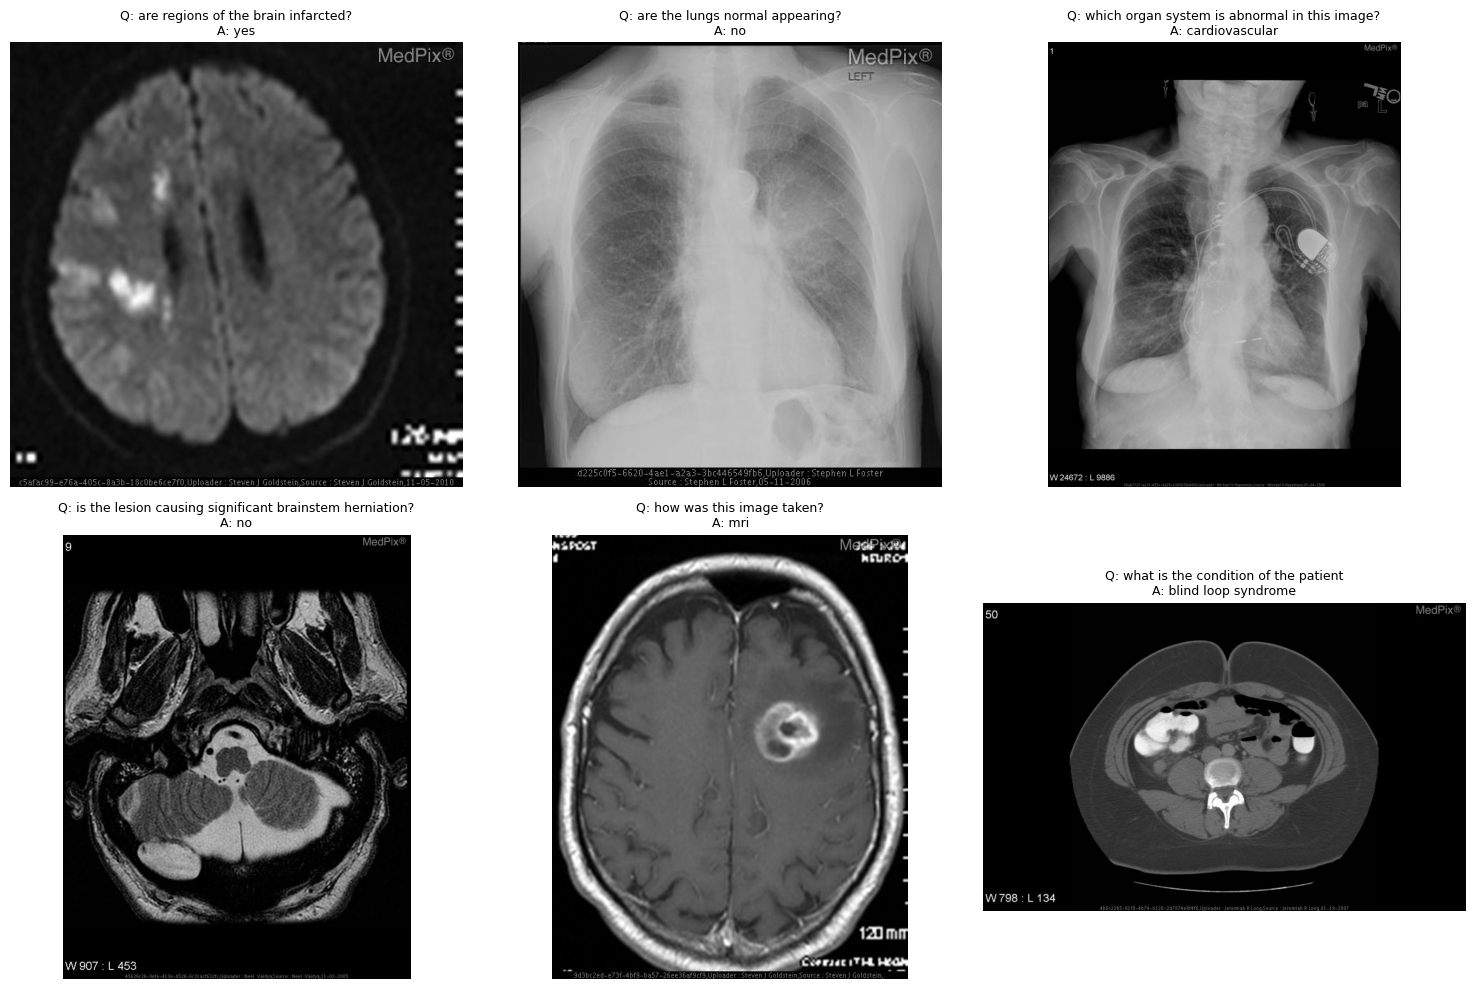

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, ax in enumerate(axes.flat):
    sample = ds['train'][idx]
    ax.imshow(sample['image'])
    q = sample['question'][:60]
    a = str(sample['answer'])[:40]
    ax.set_title(f"Q: {q}\nA: {a}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# Cell - Open vs Closed distribution
train_df = ds['train'].to_pandas().drop(columns=['image'])
test_df = ds['test'].to_pandas().drop(columns=['image'])

def classify_question(answer):
    return 'closed' if answer.strip().lower() in ['yes', 'no'] else 'open'

train_df['type'] = train_df['answer'].apply(classify_question)
test_df['type'] = test_df['answer'].apply(classify_question)

print("=== Train Split ===")
print(train_df['type'].value_counts())
print(f"Closed: {(train_df['type']=='closed').mean()*100:.1f}%")
print(f"Open:   {(train_df['type']=='open').mean()*100:.1f}%")

print("\n=== Test Split ===")
print(test_df['type'].value_counts())
print(f"Closed: {(test_df['type']=='closed').mean()*100:.1f}%")
print(f"Open:   {(test_df['type']=='open').mean()*100:.1f}%")

print("\n=== Open-ended answer diversity ===")
open_train = train_df[train_df['type'] == 'open']
print(f"Unique open answers (train): {open_train['answer'].nunique()}")
print(f"\nTop 15 open answers:")
print(open_train['answer'].value_counts().head(15))

=== Train Split ===
type
closed    940
open      853
Name: count, dtype: int64
Closed: 52.4%
Open:   47.6%

=== Test Split ===
type
closed    251
open      200
Name: count, dtype: int64
Closed: 55.7%
Open:   44.3%

=== Open-ended answer diversity ===
Unique open answers (train): 430

Top 15 open answers:
answer
axial                                   31
right                                   20
pa                                      14
left                                    13
ct                                      10
brain                                    8
x-ray                                    7
with contrast                            7
fat                                      7
diffuse                                  7
pancreas                                 6
bilateral                                6
right sided pleural effusion             6
5.6cm focal, predominantly hypodense     6
left kidney                              6
Name: count, dtype: int64


In [20]:
torch.version.cuda

'12.1'